# Imports 

In [20]:
import os
from sklearn import linear_model
import importlib
import numpy as np


#Resurse proprii functii scrie in .py

import resurse.dataPlot
import resurse.gradient
import resurse.errors
import resurse.trainPlots

importlib.reload(resurse.dataPlot)
importlib.reload(resurse.gradient)
importlib.reload(resurse.errors)
importlib.reload(resurse.trainPlots)

from resurse.normalizare import normalizareZ
import resurse.errors as err
import resurse.gradient as myRegressor
import resurse.dataPlot as dp
from resurse.readCSV import ReadDoubleInputCSV,ReadSingleInputCSV
from resurse.trainPlots import UniSelectTVdata, BiSelectTVdata, genericTVdata, Compare_ValidationVSComputed ,Compare_ValidationVSComputed3D , kFodsCrossTrainData

## Metoda de gradient descrescător

Presupunem cazul unei regresii multi-variate (*m* atribute):  
$f(x, \mathbf{w}) = w_0 + w_1 \cdot x_1 + w_2 \cdot x_2 + \ldots + w_m \cdot x_m$.  
Se dorește identificarea valorilor optime pentru coeficienții $\mathbf{w} = \{w_0, w_1, \ldots \}$ știindu-se un set de *n* exemple de antrenament de forma $(\mathbf{x}^i, y^i)$, cu $i = 1, 2, \ldots, n$,  
$\mathbf{x}^i = (x_1^i, x_2^i, \ldots, x_m^i)$.

- datele de antrenament: $(\mathbf{x}^i, y^i), i = 1, 2, \ldots, n$
- parametrii algoritmului GD: rata de învățare $(\eta)$, numărul de iterații/epoci
- valorile optime ale coeficienților $\mathbf{w}$

- se inițializează cei $m + 1$ coeficienți $\mathbf{w}$ cu 0 (sau cu valori reale oarecare din $[0, 1]$)
- se repetă (pentru un număr de iterații/epoci):
  - pentru fiecare exemplu $\mathbf{x}^i$ din $\mathcal{D}$ ($i = 1, 2, \ldots, n$):
    - se estimează valoarea lui $\hat{y}^i$:  
      $y^i_{computed} = f(\mathbf{x}^i, \mathbf{w})$
    - se stabilește eroarea între estimarea lui $y^i$ și valoarea reală/corectă a lui $y$  
      $(err = y^i_{computed} - y^i)$
    - se modifică/îmbunătățesc coeficienții $\mathbf{w}$ ținând cont de eroare și de rata de învățare:  
      $$\mathbf{w}' = \mathbf{w} - \eta \cdot err \cdot \mathbf{x}^i$$


# Functii :

## - Regresie liniara Gradient Descent - stocastic 

### - cu tool

In [2]:
def SGDtool(inputs,outputs):
    regressor = linear_model.SGDRegressor(
        alpha = 0.01, 
        max_iter = 1000,
        eta0 = 0.001
    )
    regressor.fit(inputs, outputs)
    return regressor.intercept_[0],regressor.coef_.tolist(),regressor

### - cod propriu

In [3]:
def SGDcode(inputs,outputs):
    return myRegressor.fit(inputs,outputs)

## - Regresie liniara Gradient Descent - batch

### - cu tool

In [4]:
def BGDTool(inputs,outputs):
    model = linear_model.SGDRegressor(
        max_iter=1000,
        tol=None,   # sa nu se opreasca
        learning_rate='constant',
        eta0=0.001,
        average=True,   # media coeficientilor
        shuffle=False,      # nu amestecă datele 
        random_state=42
    )
    model.fit(inputs, outputs)
    
    return model.intercept_[0],model.coef_,model

### - cu cod propriu

In [5]:
def BGDCode(inputs,outputs):
    return myRegressor.batchfit(inputs,outputs)

## Clasificare Regresie Logistica 

### tool

In [6]:
def LogisticRegressionTool(inputs,outputs):
    regressor = linear_model.LogisticRegression(
        max_iter = 1000,
    )
    regressor.fit(inputs, outputs)
    return regressor.intercept_[0],regressor.coef_[0].tolist(),regressor

### cod propriu

In [7]:
def LogisticRegressionCode(inputs,outputs):
    return myRegressor.logistic_fit(inputs,outputs)

# Probleme :


## - Problema 1 : Ce îi poate face pe oameni fericiți? :

### a. Produsul Intern brut

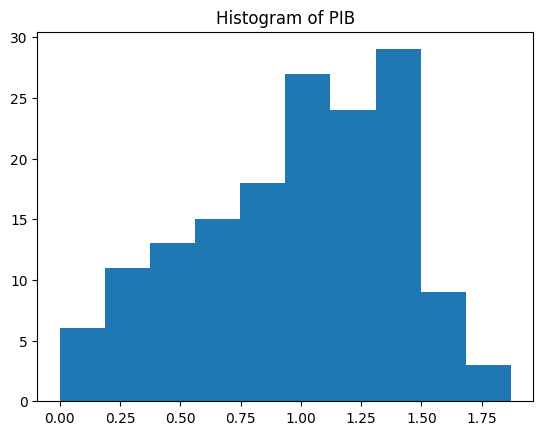

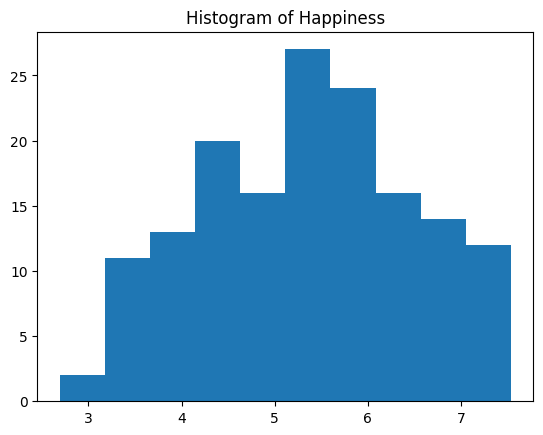

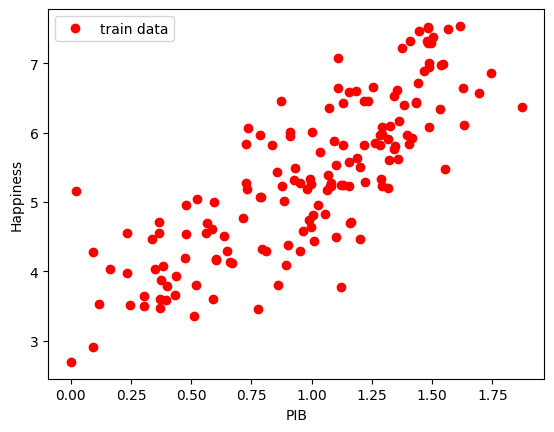

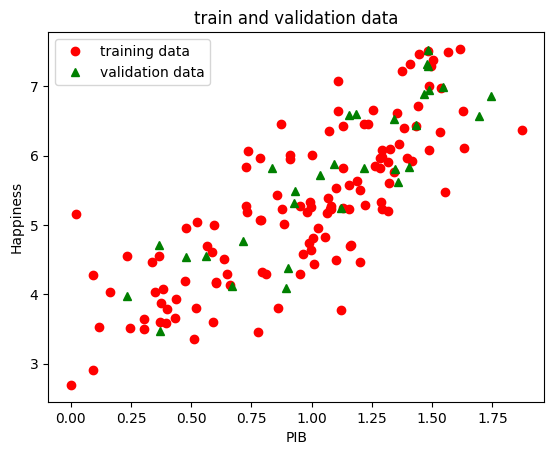

======================================================= STOCASTIC =======================================================

the learnt model tool: f(x) =  2.6085804367097785  +  2.5305570899562855  * x
the learnt model code: f(x) =  3.2431531543099545  +  2.11714113305029  * x


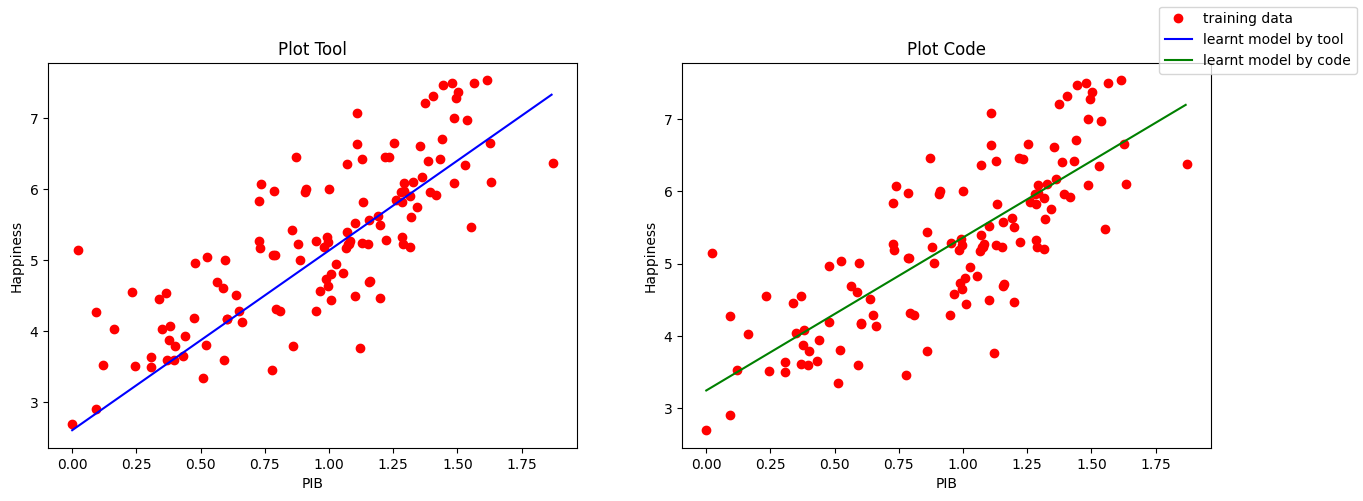

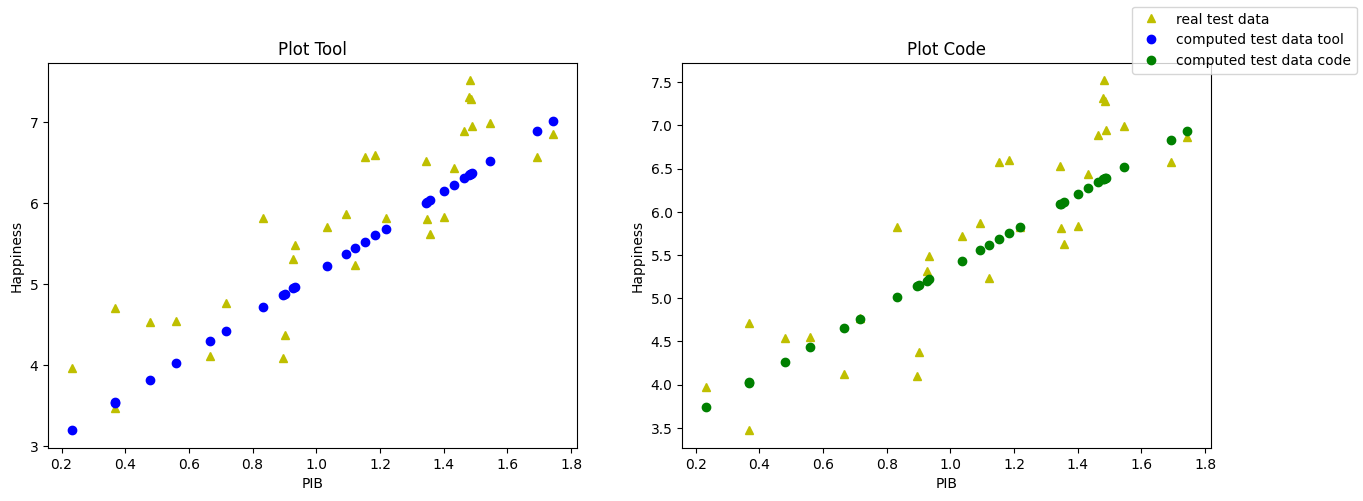

Erori outputs:
Eroare tool manuala : 0.41308459763901745
Eroare tool cu tool : 0.3247708205372529
Eroare code manuala : 0.41308459763901756
Eroare code cu tool : 0.3247708205372529
======================================================= BATCH-URI =======================================================

the learnt model tool: f(x) =  3.1699697600799386  +  2.1557400191803313  * x
the learnt model code: f(x) =  2.3010979998855556  +  2.3057590795139973  * x


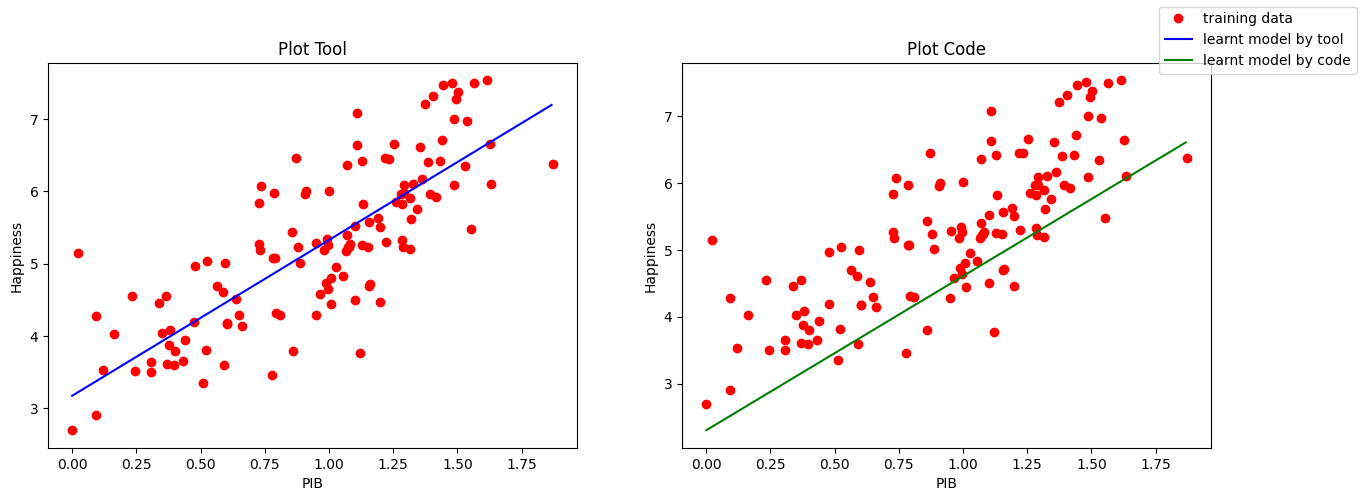

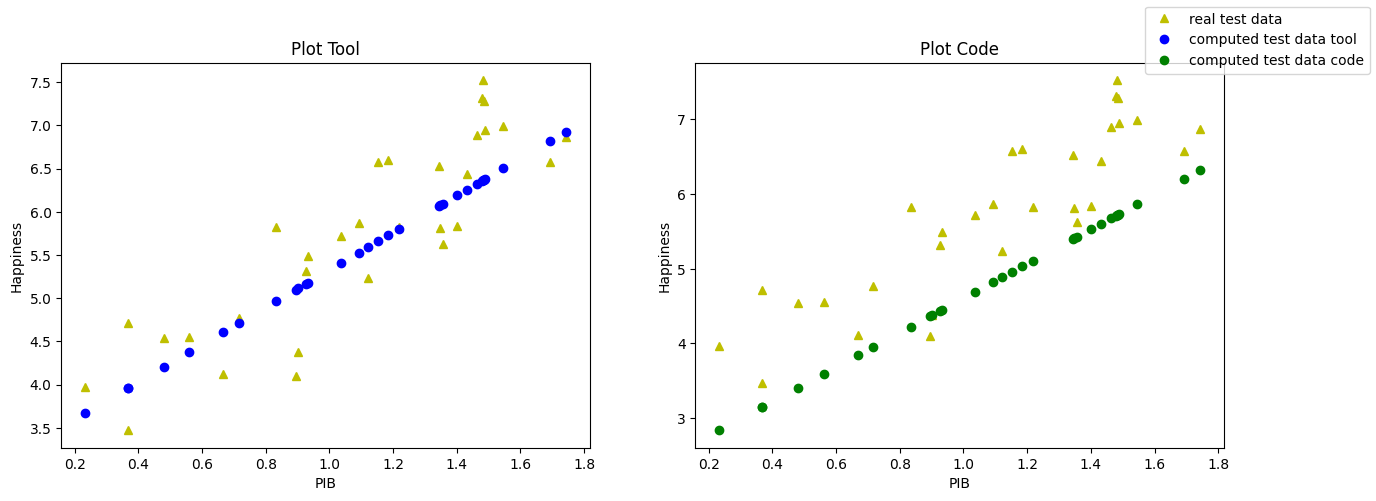

Erori outputs:
Eroare tool manuala : 0.33323976049370024
Eroare tool cu tool : 1.1066345345057327
Eroare code manuala : 0.33323976049370035
Eroare code cu tool : 1.1066345345057325


In [41]:
# Citim datele
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'dataLab6','2017.csv' )

inputs,outputs = ReadSingleInputCSV(filePath,'Economy..GDP.per.Capita.','Happiness.Score')
inputs = [float(el) for el in inputs]
outputs = [float(el) for el in outputs]

#histograma
dp.plotDataHistogram(inputs,'PIB')
dp.plotDataHistogram(outputs,'Happiness')

#plot data liniar
dp.PlotLiniarData(inputs,outputs,'PIB','Happiness')

#train and validation inputs and outputs
TI,TO,VI,VO = UniSelectTVdata(inputs,outputs,'PIB','Happiness',seed=54)

xx = [[el] for el in TI]

#Stocastic Gradient Descent
print ("======================================================= STOCASTIC =======================================================" )
print()

#tool sgd stocastic
tw0,coef_,regressor = SGDtool(xx,TO)
tw1 = coef_[0]
print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x')

#code propriu sgd
cw0,coef_ = SGDcode(xx,TO)
cw1 = coef_[0]
print('the learnt model code: f(x) = ', cw0, ' + ', cw1, ' * x')

#Plot pentru Learning data din tool si code si compararea lor
dp.Compare_LiniarData(TI,TO,tw0,tw1,cw0,cw1,'PIB','Happiness')

#tool/code computed data toolComputed , cc = codeComputed
tc = regressor.predict([[x] for x in VI])
cc = myRegressor.predict([[x] for x in VI],coef_)


#Plot pentru Validation data din tool si code si compararea lor
Compare_ValidationVSComputed(VI,VO,tc,cc,'PIB','Happiness')

#Erori outputs
print("Erori outputs:")
print(f"Eroare tool manuala : {err.ManualError(tc, VO)}")
print(f"Eroare tool cu tool : {err.ManualError(cc, VO)}")
print(f"Eroare code manuala : {err.ToolError(tc, VO)}")
print(f"Eroare code cu tool : {err.ToolError(cc, VO)}")

#Batch-uri
print("======================================================= BATCH-URI =======================================================")
print()

tw0,coef_,regressor = BGDTool(xx,TO)
tw1 = coef_[0]

print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x')

cw0,coef_ = BGDCode(xx,TO)
cw1 = coef_[0]
print('the learnt model code: f(x) = ', cw0, ' + ', cw1, ' * x')

#Plot pentru Learning data din tool si code si compararea lor
dp.Compare_LiniarData(TI,TO,tw0,tw1,cw0,cw1,'PIB','Happiness')

#tool/code computed data toolComputed , cc = codeComputed
tc = regressor.predict([[x] for x in VI])
cc = myRegressor.predict([[x] for x in VI],coef_)

#Plot pentru Validation data din tool si code si compararea lor
Compare_ValidationVSComputed(VI,VO,tc,cc,'PIB','Happiness')

print("Erori outputs:")
print(f"Eroare tool manuala : {err.ManualError(tc, VO)}")
print(f"Eroare tool cu tool : {err.ManualError(cc, VO)}")
print(f"Eroare code manuala : {err.ToolError(tc, VO)}")
print(f"Eroare code cu tool : {err.ToolError(cc, VO)}")

### b. PIB si gradul de libertate

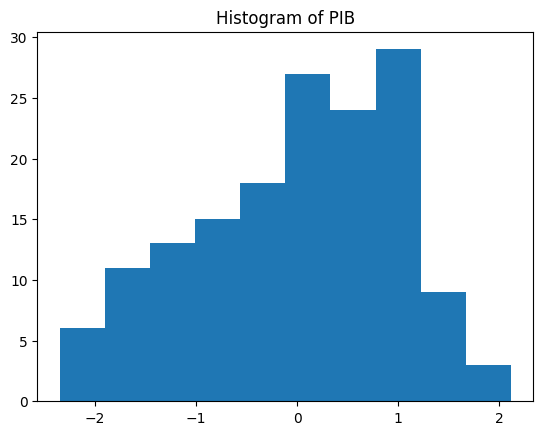

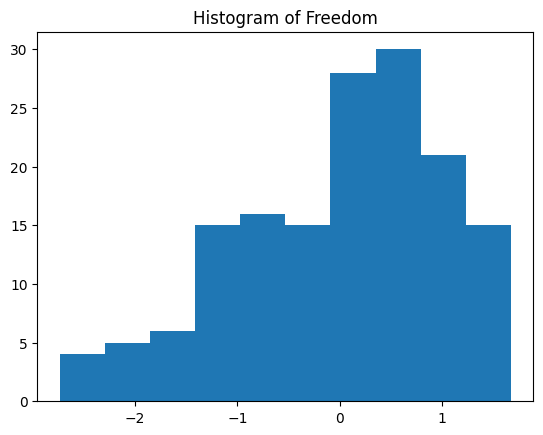

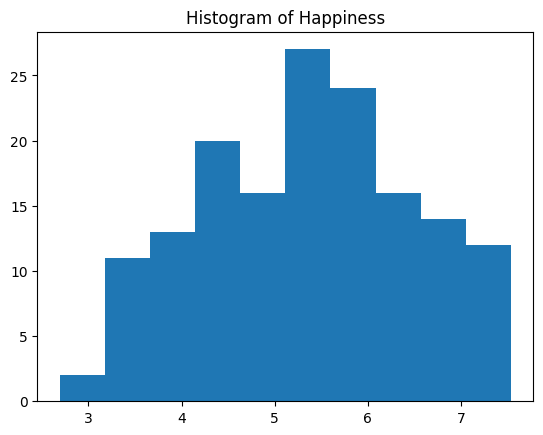

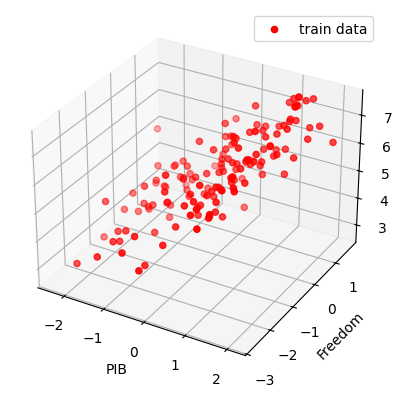

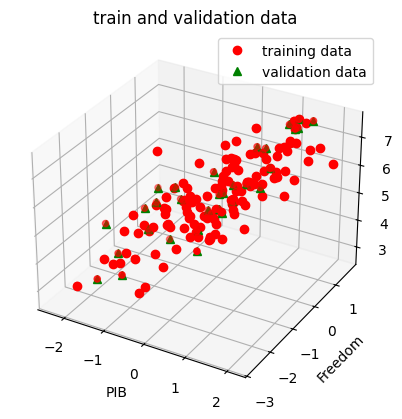

======================================================= STOCASTIC =======================================================

the learnt model tool: f(x) =  5.020153669599244  +  0.7718871928831911  * x1 + 0.3475831269472088  * x2
the learnt model code: f(x) =  5.320673871806942  +  0.7868968288345184  * x + 0.34514064512834725  * x2


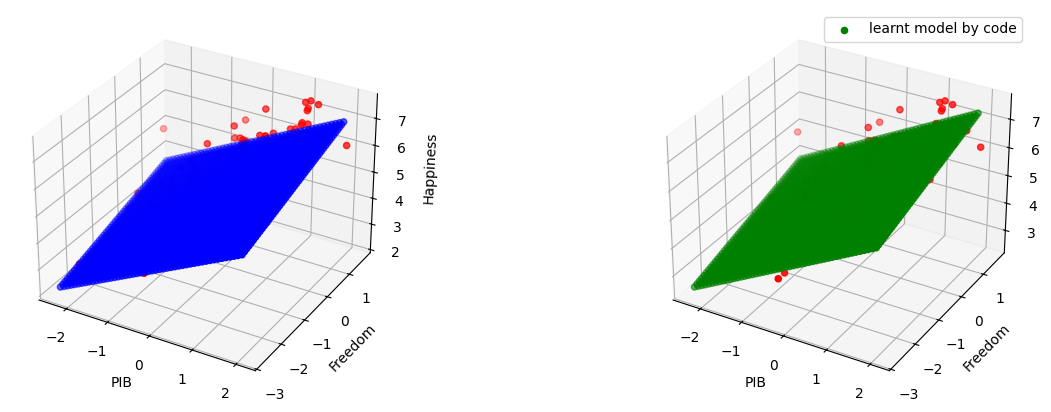

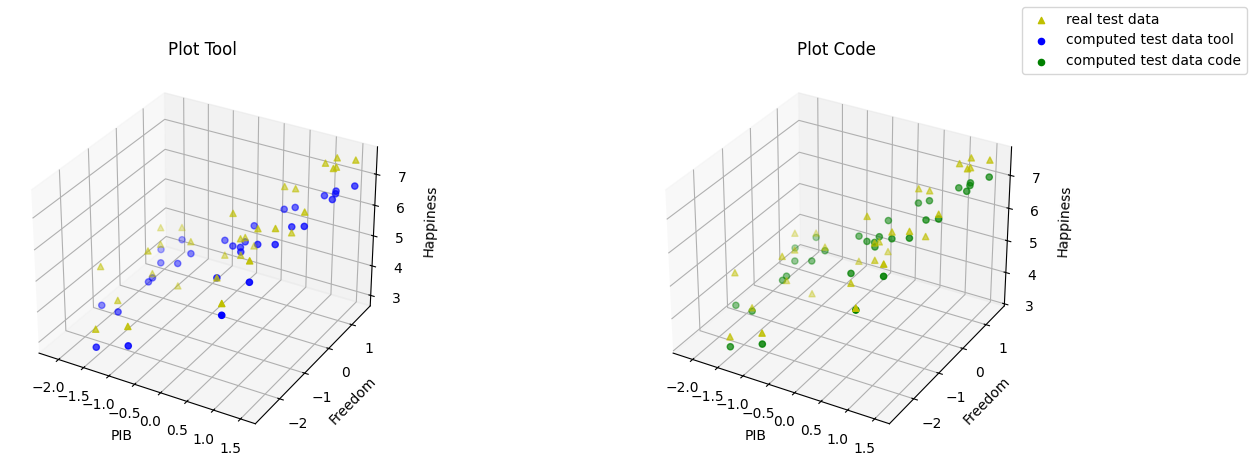

Erori outputs:
Eroare tool manuala : 0.4639195757873131
Eroare tool cu tool : 0.27839150555221837
Eroare code manuala : 0.4639195757873132
Eroare code cu tool : 0.2783915055522184
======================================================= BATCH-URI =======================================================

the learnt model tool: f(x) =  5.279665641307843  +  0.7821490407628159  * x1 + 0.34499724835029055  * x2
the learnt model code: f(x) =  3.3748837268688634  +  0.5925075837219785  * x + 0.2931289634802382  * x2


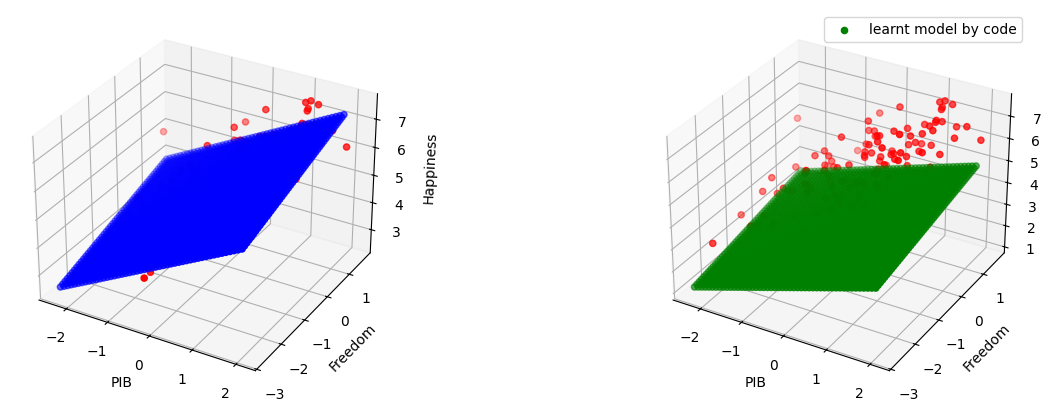

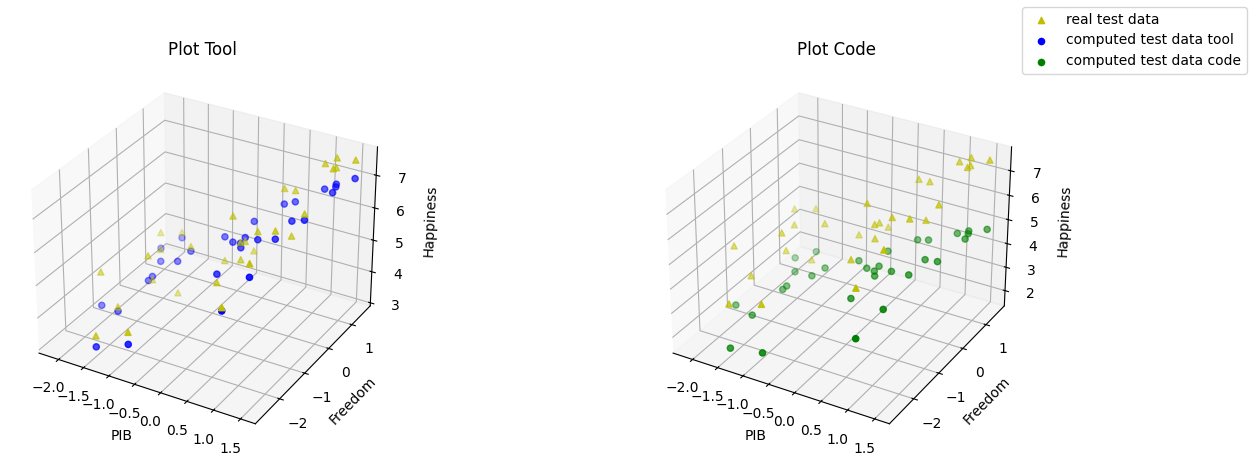

Erori outputs:
Eroare tool manuala : 0.2932538808889938
Eroare tool cu tool : 4.632696947743391
Eroare code manuala : 0.29325388088899385
Eroare code cu tool : 4.6326969477433915


In [9]:
# Citim datele
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'dataLab6','2017.csv' )

inputsFirst,inputsSecond,outputs = ReadDoubleInputCSV(filePath,'Economy..GDP.per.Capita.','Freedom','Happiness.Score')
inputsFirst = [float(el) for el in inputsFirst]
inputsSecond = [float(el) for el in inputsSecond]
outputs = [float(el) for el in outputs]

#normalizare
inputsFirst = normalizareZ(inputsFirst)
inputsSecond = normalizareZ(inputsSecond)

#histograma
dp.plotDataHistogram(inputsFirst,'PIB')
dp.plotDataHistogram(inputsSecond,'Freedom')
dp.plotDataHistogram(outputs,'Happiness')

#plot data liniar
dp.Plot3DLiniardata(inputsFirst,inputsSecond,outputs,'PIB','Freedom','Happiness')

#train and validation inputs and outputs
TIF,TIS,TO,VIF,VIS,VO = BiSelectTVdata(inputsFirst,inputsSecond,outputs,'PIB','Freedom','Happiness')

xx = [[el1,el2] for el1,el2 in zip(TIF,TIS)]

#Stocastic Gradient Descent
print ("======================================================= STOCASTIC =======================================================" )
print()

#tool sgd stocastic
tw0,coef_,regressor = SGDtool(xx,TO)
tw1,tw2 = coef_[0],coef_[1]
print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x1 +', tw2,' * x2')

#code propriu sgd
cw0,coef_ = SGDcode(xx,TO)
cw1,cw2 = coef_[0],coef_[1]
print('the learnt model code: f(x) = ', cw0, ' + ', cw1, ' * x +', cw2,' * x2')

#Plot pentru Learning data din tool si code si compararea lor
dp.Compare_PlaneData(TIF,TIS,TO,tw0,tw1,tw2,cw0,cw1,cw2,'PIB','Freedom','Happiness')

#tool/code computed data toolComputed , cc = codeComputed
tc = regressor.predict([[x1,x2] for x1,x2 in zip(VIF,VIS)])
cc = myRegressor.predict([[x1,x2] for x1,x2 in zip(VIF,VIS)],coef_)

#Plot pentru Validation data din tool si code si compararea lor
Compare_ValidationVSComputed3D(VIF,VIS,VO,tc,cc,'PIB','Freedom','Happiness')

#Erori outputs
print("Erori outputs:")
print(f"Eroare tool manuala : {err.ManualError(tc, VO)}")
print(f"Eroare tool cu tool : {err.ManualError(cc, VO)}")
print(f"Eroare code manuala : {err.ToolError(tc, VO)}")
print(f"Eroare code cu tool : {err.ToolError(cc, VO)}")

print ("======================================================= BATCH-URI =======================================================" )
print()

#tool sgd stocastic
tw0,coef_,regressor = BGDTool(xx,TO)
tw1,tw2 = coef_[0],coef_[1]
print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x1 +', tw2,' * x2')

#code propriu sgd
cw0,coef_ = BGDCode(xx,TO)
cw1,cw2 = coef_[0],coef_[1]
print('the learnt model code: f(x) = ', cw0, ' + ', cw1, ' * x +', cw2,' * x2')

#Plot pentru Learning data din tool si code si compararea lor
dp.Compare_PlaneData(TIF,TIS,TO,tw0,tw1,tw2,cw0,cw1,cw2,'PIB','Freedom','Happiness')

#tool/code computed data toolComputed , cc = codeComputed
tc = regressor.predict([[x1,x2] for x1,x2 in zip(VIF,VIS)])
cc = myRegressor.predict([[x1,x2] for x1,x2 in zip(VIF,VIS)],coef_)

#Plot pentru Validation data din tool si code si compararea lor
Compare_ValidationVSComputed3D(VIF,VIS,VO,tc,cc,'PIB','Freedom','Happiness')

#Erori outputs
print("Erori outputs:")
print(f"Eroare tool manuala : {err.ManualError(tc, VO)}")
print(f"Eroare tool cu tool : {err.ManualError(cc, VO)}")
print(f"Eroare code manuala : {err.ToolError(tc, VO)}")
print(f"Eroare code cu tool : {err.ToolError(cc, VO)}")

## - Problema 2 : Clasificarea țesuturilor cancerigene

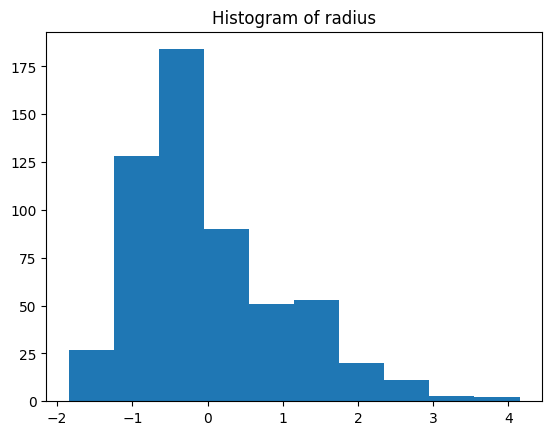

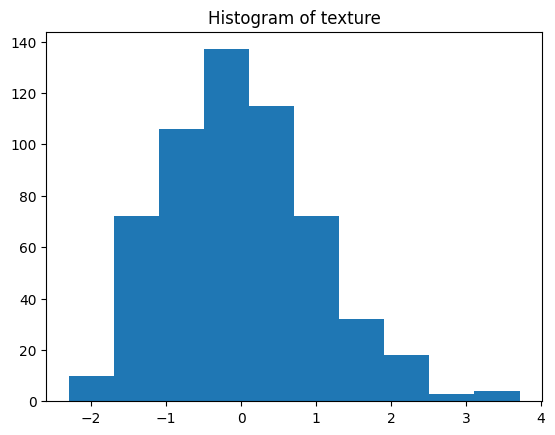

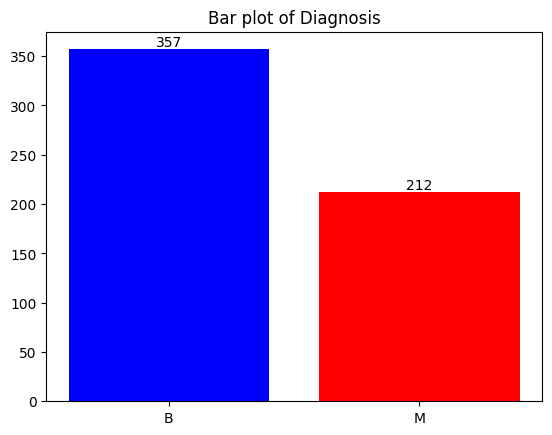

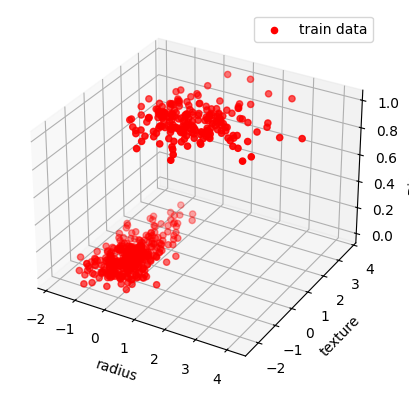

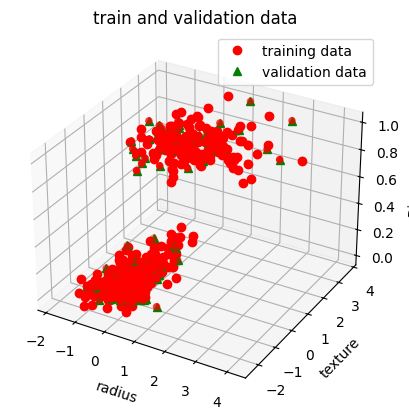

the learnt model tool: f(x) =  -0.8269768741755417  +  4.389247056375035  * x1 + 1.0840083388949147  * x2
the learnt model code: f(x) =  -0.8438341913414515  +  5.720365874064469  * x + 1.2883578767805857  * x2


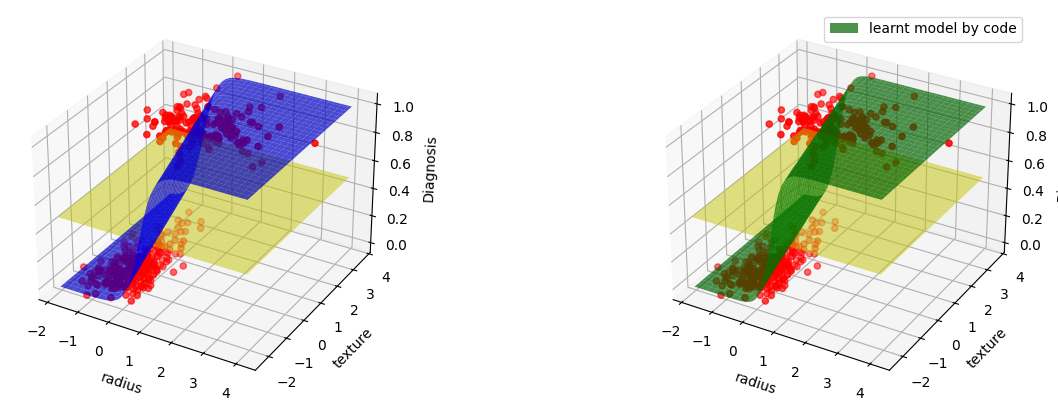

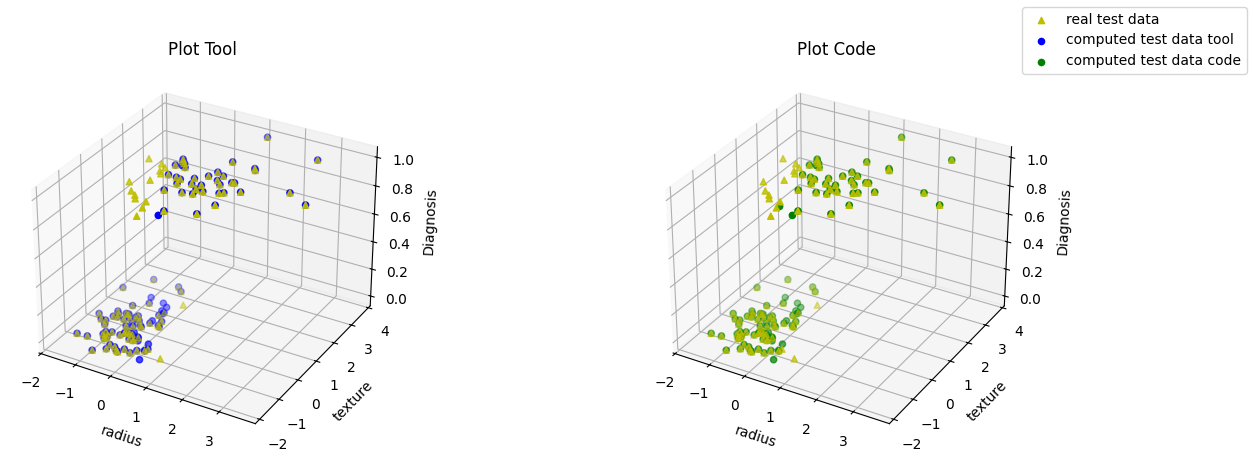

Performance on training set:

Confusion Matrix:
 [[62  2]
 [13 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.97      0.89        64
           1       0.95      0.74      0.83        50

    accuracy                           0.87       114
   macro avg       0.89      0.85      0.86       114
weighted avg       0.88      0.87      0.87       114

Performance on training set:

Confusion Matrix:
 [[37, 3], [13, 61]]

Classification Report:
 Accuracy: 0.8596491228070176
, Precision: 0.925
, Recall: 0.74


In [10]:
#Reading data
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'dataLab6','wdbc.csv' )
inputsFirst1,inputsSecond1,_ = ReadDoubleInputCSV(filePath,'radius1','texture1','Diagnosis')
inputsFirst2,inputsSecond2,_ = ReadDoubleInputCSV(filePath,'radius2','texture2','Diagnosis')
inputsFirst3,inputsSecond3,MorB = ReadDoubleInputCSV(filePath,'radius3','texture3','Diagnosis')

inputsFirst = normalizareZ([np.mean([float(el1),float(el2),float(el3)]) for el1,el2,el3 in zip(inputsFirst1,inputsFirst2,inputsFirst3)])
inputsSecond = normalizareZ([np.mean([float(el1),float(el2),float(el3)]) for el1,el2,el3 in zip(inputsSecond1,inputsSecond2,inputsSecond3)])
outputs = [1 if str(el) == 'M' else 0 for el in MorB]

#histograma
dp.plotDataHistogram(inputsFirst,'radius')
dp.plotDataHistogram(inputsSecond,'texture')
dp.plotDataBar(outputs,'Diagnosis')

#verificare liniaritate
dp.Plot3DLiniardata(inputsFirst,inputsSecond,outputs,'radius','texture','Diagnosis')

#train and validation inputs and outputs
TIF,TIS,TO,VIF,VIS,VO = BiSelectTVdata(inputsFirst,inputsSecond,outputs,'radius','texture','Diagnosis')

xx = [[el1,el2] for el1,el2 in zip(TIF,TIS)]

#tool logistic regresion 
tw0,coef_,regressor = LogisticRegressionTool(xx,TO)
tw1,tw2 = coef_[0],coef_[1]
print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x1 +', tw2,' * x2')

#code propriu logistic regresion 
cw0,coef_ = LogisticRegressionCode(xx,TO)
cw1,cw2 = coef_[0],coef_[1]
print('the learnt model code: f(x) = ', cw0, ' + ', cw1, ' * x +', cw2,' * x2')

#Plot pentru Learning data din tool si code si compararea lor
dp.Compare_SigmoidData(TIF,TIS,TO,tw0,tw1,tw2,cw0,cw1,cw2,'radius','texture','Diagnosis')

#tool/code computed data toolComputed , cc = codeComputed
tc = regressor.predict([[x1,x2] for x1,x2 in zip(VIF,VIS)])
cc = myRegressor.clasificare([[x1,x2] for x1,x2 in zip(VIF,VIS)],coef_)

#Plot pentru Validation data din tool si code si compararea lor
Compare_ValidationVSComputed3D(VIF,VIS,VO,tc,cc,'radius','texture','Diagnosis')

#Erori
cm_tool,tool_report = err.ToolErrorClassification(VO,tc)
print("Performance on training set:\n")
print(f'Confusion Matrix:\n {cm_tool}\n')
print(f'Classification Report:\n {tool_report}')
cm_code,code_report = err.ManualErrorClassification(VO,cc)
print("Performance on training set:\n")
print(f'Confusion Matrix:\n {cm_code}\n')
print(f'Classification Report:\n {code_report}')

#pentru problema optionala
BCE_computedData = myRegressor.probabiliate([[x1,x2] for x1,x2 in zip(VIF,VIS)],coef_)
BCE_realData = VO

## daca o leziune (dintr-o mamografie) caracterizata printr-o textura de valoare 10 si o raza de valoare 18 este leziune maligna sau benigna

In [11]:
val = normalizareZ([(10,18)])

#tool logistic regresion
print("Tool")
print("Leziune maligna" if regressor.predict(val) == 1 else "Leziune benigna")
print("Cod propriu")
print("Leziune maligna" if myRegressor.clasificare(val,coef_) == 1 else "Leziune benigna")

Tool
Leziune benigna
Cod propriu
Leziune benigna


## - Problema 3 : Ce fel de floare preferi?

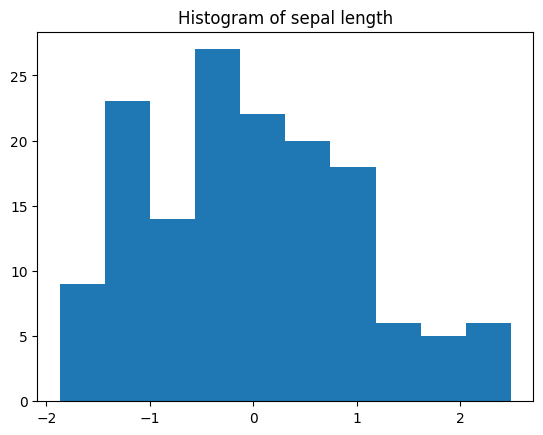

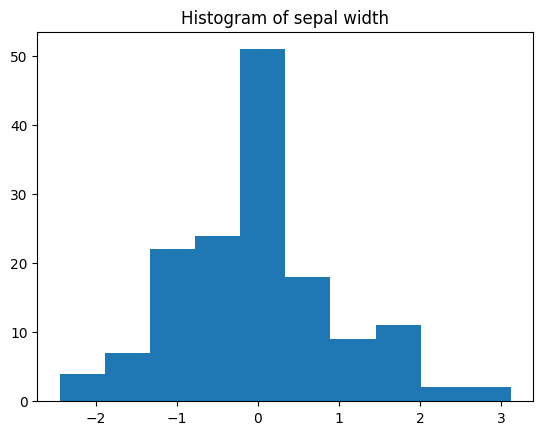

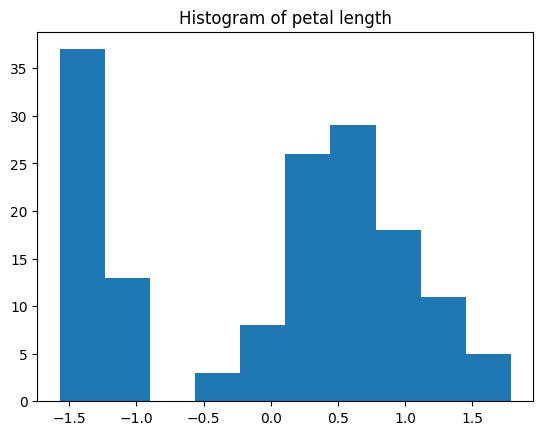

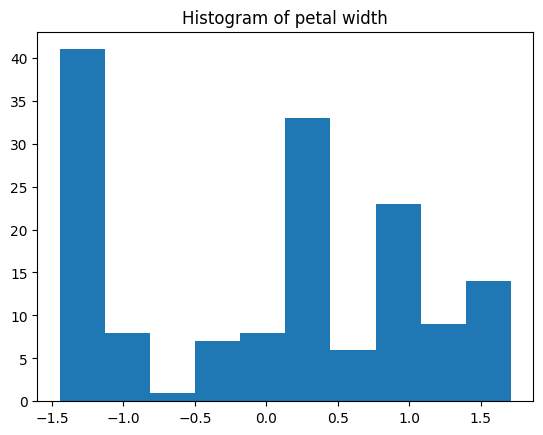

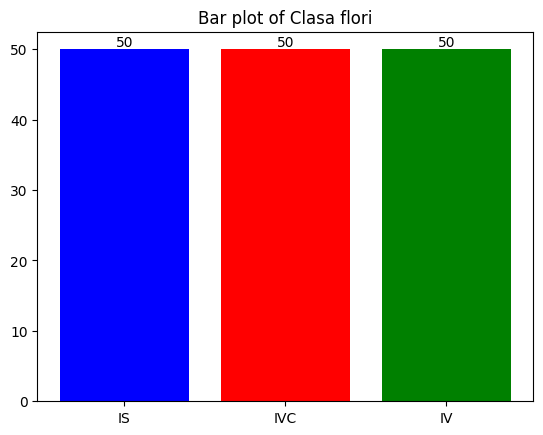

In [12]:
#Reading data
filePath = os.path.join(crtDir, 'dataLab6','iris.csv')
inputsFirst,inputsSecond,_ = ReadDoubleInputCSV(filePath,'sepal.length','sepal.width','class')
inputsThird,inputsForth,classFloare = ReadDoubleInputCSV(filePath,'petal.length','petal.width','class')
inputsFirst = normalizareZ([float(el) for el in inputsFirst])
inputsSecond = normalizareZ([float(el) for el in inputsSecond])
inputsThird = normalizareZ([float(el) for el in inputsThird])
inputsForth = normalizareZ([float(el) for el in inputsForth])

outputs = [str(el) for el in classFloare]

#histograma
dp.plotDataHistogram(inputsFirst,'sepal length')
dp.plotDataHistogram(inputsSecond,'sepal width')
dp.plotDataHistogram(inputsThird,'petal length')
dp.plotDataHistogram(inputsForth,'petal width')
dp.plotDataBar2(outputs,'Clasa flori')

#train and validation inputs and outputs
xx = [[el1,el2,el3,el4] for el1,el2,el3,el4 in zip(inputsFirst,inputsSecond,inputsThird,inputsForth)]
TI,T,VI,V = genericTVdata(xx,outputs,seed=4200101)


## impart probleam regresiei logistice multiple in 3 regresii logistice binare 

In [13]:
print ("================================================= CLASIFICAREA IRIS SETOASA=================================================")
print()

#set valori de output corespunzatoare clasificari
TO = [1 if str(el) == 'Iris-setosa' else 0 for el in T]
VO = [1 if str(el) == 'Iris-setosa' else 0 for el in V]

#tool logistic regresion
tw0,coef_,regressor = LogisticRegressionTool(TI,TO)
tw1,tw2,tw3,tw4 = coef_[0],coef_[1],coef_[2],coef_[3]
print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x1 +', tw2,' * x2 +',tw3,' * x3 +',tw4,' * x4')

#code propriu logistic regresion
cw0,coefIS = LogisticRegressionCode(TI,TO)
cw1,cw2,cw3,cw4 = coef_[0],coef_[1],coef_[2],coef_[3]
print('the learnt model code: f(x) = ', cw0, ' + ', cw1, ' * x1 +', cw2,' * x2 +',cw3,' * x3 +',cw4,' * x4')


#Computed data 
tc = regressor.predict(VI)
cc = myRegressor.clasificare(VI,coefIS)

#Erori
cm_tool,tool_report = err.ToolErrorClassification(VO,tc)
print("Performance on training set:\n")
print(f'Confusion Matrix:\n {cm_tool}\n')
print(f'Classification Report:\n {tool_report}')
cm_code,code_report = err.ManualErrorClassification(VO,cc)
print("Performance on training set:\n")
print(f'Confusion Matrix:\n {cm_code}\n')
print(f'Classification Report:\n {code_report}')

================================================= CLASIFICAREA IRIS SETOASA=================================================

the learnt model tool: f(x) =  -2.4044312383040847  +  -1.0523103451384344  * x1 + 1.1373165248990964  * x2 + -1.7142254015161082  * x3 + -1.5905163355543583  * x4
the learnt model code: f(x) =  -2.146489186333515  +  -1.0523103451384344  * x1 + 1.1373165248990964  * x2 + -1.7142254015161082  * x3 + -1.5905163355543583  * x4
Performance on training set:

Confusion Matrix:
 [[22  0]
 [ 0  8]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Performance on training set:

Confusion Matrix:
 [[8, 0], [0, 22]]

Classification Report:
 Accuracy: 1.0
, Precision: 1.0
, Re

In [14]:
print ("================================================ CLASIFICAREA IRIS VERSICOLOR===============================================")
print()

#set valori de output corespunzatoare clasificari
TO = [1 if str(el) == 'Iris-versicolor' else 0 for el in T]
VO = [1 if str(el) == 'Iris-versicolor' else 0 for el in V]

#tool logistic regresion
tw0,coef_,regressor = LogisticRegressionTool(TI,TO)
tw1,tw2,tw3,tw4 = coef_[0],coef_[1],coef_[2],coef_[3]
print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x1 +', tw2,' * x2 +',tw3,' * x3 +',tw4,' * x4')

#code propriu logistic regresion
cw0,coefIVR = LogisticRegressionCode(TI,TO)
cw1,cw2,cw3,cw4 = coef_[0],coef_[1],coef_[2],coef_[3]
print('the learnt model code: f(x) = ', cw0, ' + ', cw1, ' * x1 +', cw2,' * x2 +',cw3,' * x3 +',cw4,' * x4')


#Computed data 
tc = regressor.predict(VI)
cc = myRegressor.clasificare(VI,coefIVR)

#Erori
cm_tool,tool_report = err.ToolErrorClassification(VO,tc)
print("Performance on training set:\n")
print(f'Confusion Matrix:\n {cm_tool}\n')
print(f'Classification Report:\n {tool_report}')
cm_code,code_report = err.ManualErrorClassification(VO,cc)
print("Performance on training set:\n")
print(f'Confusion Matrix:\n {cm_code}\n')
print(f'Classification Report:\n {code_report}')

================================================ CLASIFICAREA IRIS VERSICOLOR===============================================

the learnt model tool: f(x) =  -0.9067373947816305  +  -0.09376706203030573  * x1 + -1.0037335481641583  * x2 + 0.8084181008080883  * x3 + -0.5727130783363542  * x4
the learnt model code: f(x) =  -0.935306458986699  +  -0.09376706203030573  * x1 + -1.0037335481641583  * x2 + 0.8084181008080883  * x3 + -0.5727130783363542  * x4
Performance on training set:

Confusion Matrix:
 [[19  1]
 [ 5  5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.95      0.86        20
           1       0.83      0.50      0.62        10

    accuracy                           0.80        30
   macro avg       0.81      0.72      0.74        30
weighted avg       0.81      0.80      0.78        30

Performance on training set:

Confusion Matrix:
 [[6, 1], [4, 19]]

Classification Report:
 Accuracy: 0.8333333333333334
, Pr

In [15]:
print ("================================================ CLASIFICAREA IRIS VIRGINICA===============================================")
print()
#set valori de output corespunzatoare clasificari
TO = [1 if str(el) == 'Iris-virginica' else 0 for el in T]
VO = [1 if str(el) == 'Iris-virginica' else 0 for el in V]

#tool logistic regresion
tw0,coef_,regressor = LogisticRegressionTool(TI,TO)
tw1,tw2,tw3,tw4 = coef_[0],coef_[1],coef_[2],coef_[3]
print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x1 +', tw2,' * x2 +',tw3,' * x3 +',tw4,' * x4')

#code propriu logistic regresion
cw0,coefIV = LogisticRegressionCode(TI,TO)
cw1,cw2,cw3,cw4 = coef_[0],coef_[1],coef_[2],coef_[3]
print('the learnt model code: f(x) = ', cw0, ' + ', cw1, ' * x1 +', cw2,' * x2 +',cw3,' * x3 +',cw4,' * x4')


#Computed data 
tc = regressor.predict(VI)
cc = myRegressor.clasificare(VI,coefIV)

#Erori
cm_tool,tool_report = err.ToolErrorClassification(VO,tc)
print("Performance on training set:\n")
print(f'Confusion Matrix:\n {cm_tool}\n')
print(f'Classification Report:\n {tool_report}')
cm_code,code_report = err.ManualErrorClassification(VO,cc)
print("Performance on training set:\n")
print(f'Confusion Matrix:\n {cm_code}\n')
print(f'Classification Report:\n {code_report}')

================================================ CLASIFICAREA IRIS VIRGINICA===============================================

the learnt model tool: f(x) =  -3.5823668833365856  +  0.22941486432429972  * x1 + -0.7021999068763128  * x2 + 2.279166358768295  * x3 + 2.807775568843273  * x4
the learnt model code: f(x) =  -3.520965822967658  +  0.22941486432429972  * x1 + -0.7021999068763128  * x2 + 2.279166358768295  * x3 + 2.807775568843273  * x4
Performance on training set:

Confusion Matrix:
 [[17  1]
 [ 0 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.92      1.00      0.96        12

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Performance on training set:

Confusion Matrix:
 [[12, 1], [0, 17]]

Classification Report:
 Accuracy: 0.9666666666666667
, Precision:

specia unei flori de iris care are sepala lunga de 5.35 cm si lata de 3.85 cm, iar petala lunga de 1.25 cm si lata de 0.4cm

In [16]:
val = normalizareZ([5.35,3.85,1.25,0.4])
print(val)

procent_setosa = myRegressor.probabiliate([val],coefIS)[0]
procent_versicolor = myRegressor.probabiliate([val],coefIVR)[0]
procent_virginica = myRegressor.probabiliate([val],coefIV)[0]

print(f"Procent Iris-setosa: {procent_setosa}")
print(f"Procent Iris-versicolor: {procent_versicolor}")
print(f"Procent Iris-virginica: {procent_virginica}")

maxim = max(procent_setosa,procent_versicolor,procent_virginica)

if maxim == procent_setosa:
    print("Iris-setosa")
elif maxim == procent_versicolor:
    print("Iris-versicolor")
else:
    print("Iris-virginica")

[1.3297292327387615, 0.573485119332831, -0.7373380105707825, -1.16587634150081]
Procent Iris-setosa: 0.7967379747769904
Procent Iris-versicolor: 0.18447407961520082
Procent Iris-virginica: 0.00010490339753135558
Iris-setosa


# Cerinte optionale:
# Rezolvarea unei probleme de regresie/clasificare prin:


## - folosirea validarii încrucișate

## - Refacem Problema 1 A cu k-fold cross-validation
### In loc sa imparti set-ul de date in 2 , il impartim in k parti egale , si antrenam modelul de k ori

In [32]:
#fucntie pentru rezolvarea unui set da date
def SolveForSetStocastic(TI,TO,VI,VO):
    #tool sgd stocastic
    tw0,coef_,regressor = SGDtool(TI,TO)
    tw1 = coef_[0]
    print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x')
    
    #code propriu sgd
    cw0,coef_ = SGDcode(TI,TO)
    cw1 = coef_[0]
    print('the learnt model code: f(x) = ', cw0, ' + ', cw1, ' * x')
    
    #Plot pentru Learning data din tool si code si compararea lor
    dp.Compare_LiniarData([el[0] for el in TI],TO,tw0,tw1,cw0,cw1,'PIB','Happiness')
    
    #tool/code computed data toolComputed , cc = codeComputed
    tc = regressor.predict(VI)
    cc = myRegressor.predict(VI,coef_)
    
    
    #Plot pentru Validation data din tool si code si compararea lor
    Compare_ValidationVSComputed([el[0] for el in VI],VO,tc,cc,'PIB','Happiness')
    
    #Erori outputs
    print("Erori outputs:")
    print(f"Eroare tool manuala : {err.ManualError(tc, VO)}")
    print(f"Eroare tool cu tool : {err.ManualError(cc, VO)}")
    print(f"Eroare code manuala : {err.ToolError(tc, VO)}")
    print(f"Eroare code cu tool : {err.ToolError(cc, VO)}")
    
    return [tw0,tw1,cw0,cw1]

In [39]:
def SolveForSetBatches(TI,TO,VI,VO):
    #tool sgd batch
    tw0,coef_,regressor = BGDTool(TI,TO)
    tw1 = coef_[0]
    print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x')
    
    #code propriu Bgd
    cw0,coef_ = BGDCode(TI,TO)
    cw1 = coef_[0]
    print('the learnt model code: f(x) = ', cw0, ' + ', cw1, ' * x')
    
    #Plot pentru Learning data din tool si code si compararea lor
    dp.Compare_LiniarData([el[0] for el in TI],TO,tw0,tw1,cw0,cw1,'PIB','Happiness')
    
    #tool/code computed data toolComputed , cc = codeComputed
    tc = regressor.predict(VI)
    cc = myRegressor.predict(VI,coef_)
    
    
    #Plot pentru Validation data din tool si code si compararea lor
    Compare_ValidationVSComputed([el[0] for el in VI],VO,tc,cc,'PIB','Happiness')
    
    #Erori outputs
    print("Erori outputs:")
    print(f"Eroare tool manuala : {err.ManualError(tc, VO)}")
    print(f"Eroare tool cu tool : {err.ManualError(cc, VO)}")
    print(f"Eroare code manuala : {err.ToolError(tc, VO)}")
    print(f"Eroare code cu tool : {err.ToolError(cc, VO)}")
    
    return [tw0,tw1,cw0,cw1]

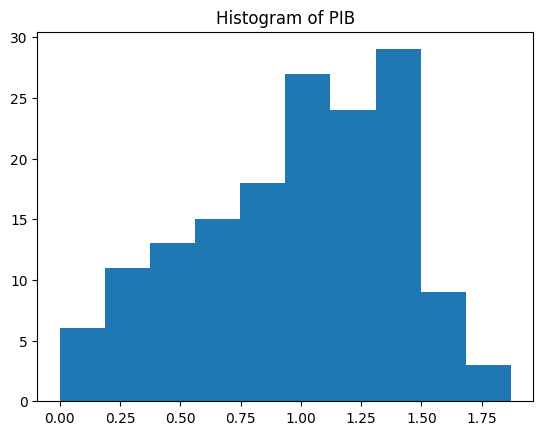

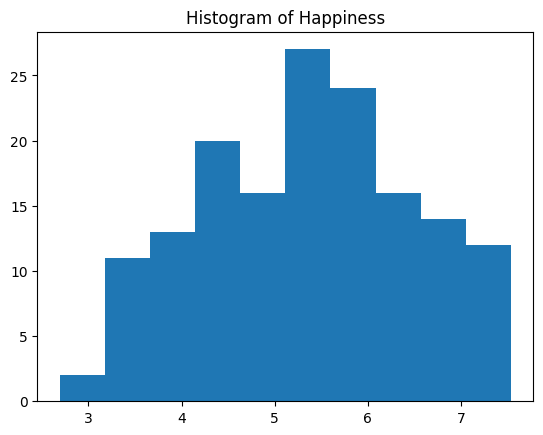

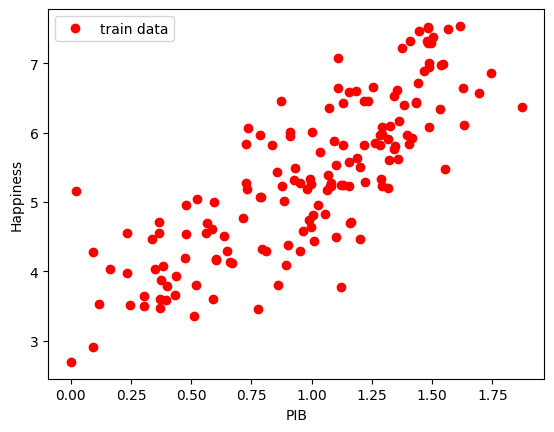

======================================================= STOCASTIC =======================================================

 < ------------- Iteration  1  -------------- >
the learnt model tool: f(x) =  2.544657762986006  +  2.6472737252049923  * x
the learnt model code: f(x) =  3.1726415524613265  +  2.2719935793001063  * x


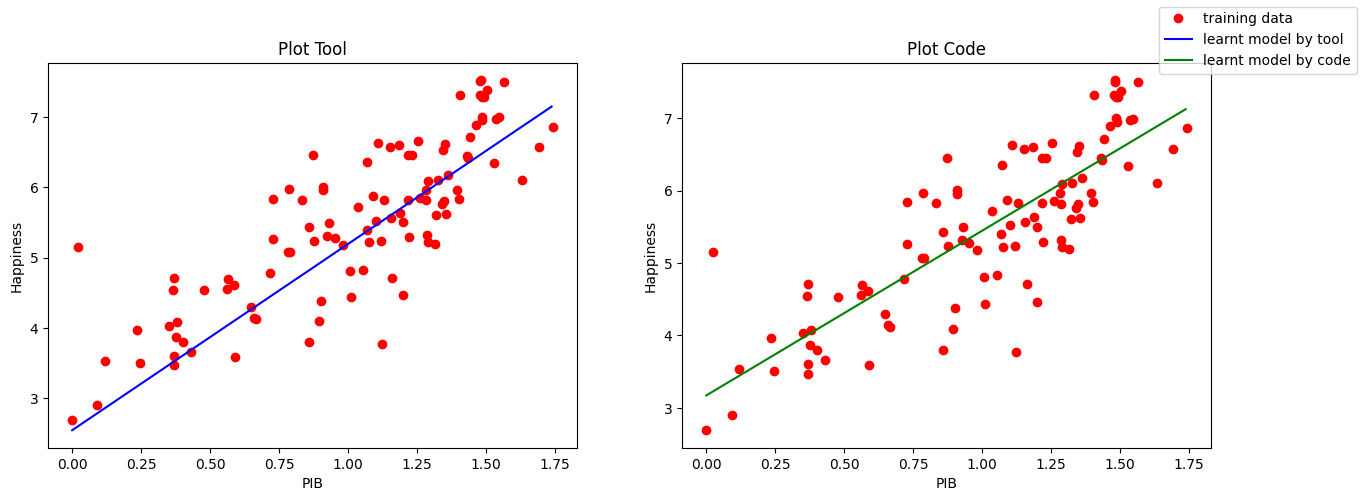

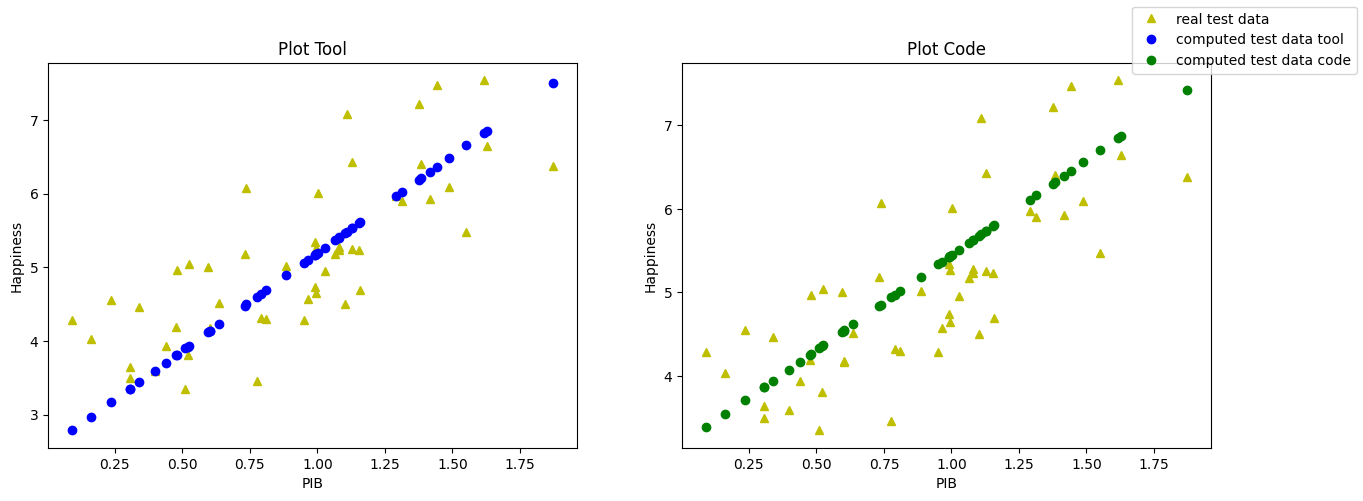

Erori outputs:
Eroare tool manuala : 0.553819838418443
Eroare tool cu tool : 0.49094628283621344
Eroare code manuala : 0.553819838418443
Eroare code cu tool : 0.4909462828362135
 < ------------- Iteration  2  -------------- >
the learnt model tool: f(x) =  2.5565262209320103  +  2.6343626477013276  * x
the learnt model code: f(x) =  3.1655970818450334  +  2.2734671963052975  * x


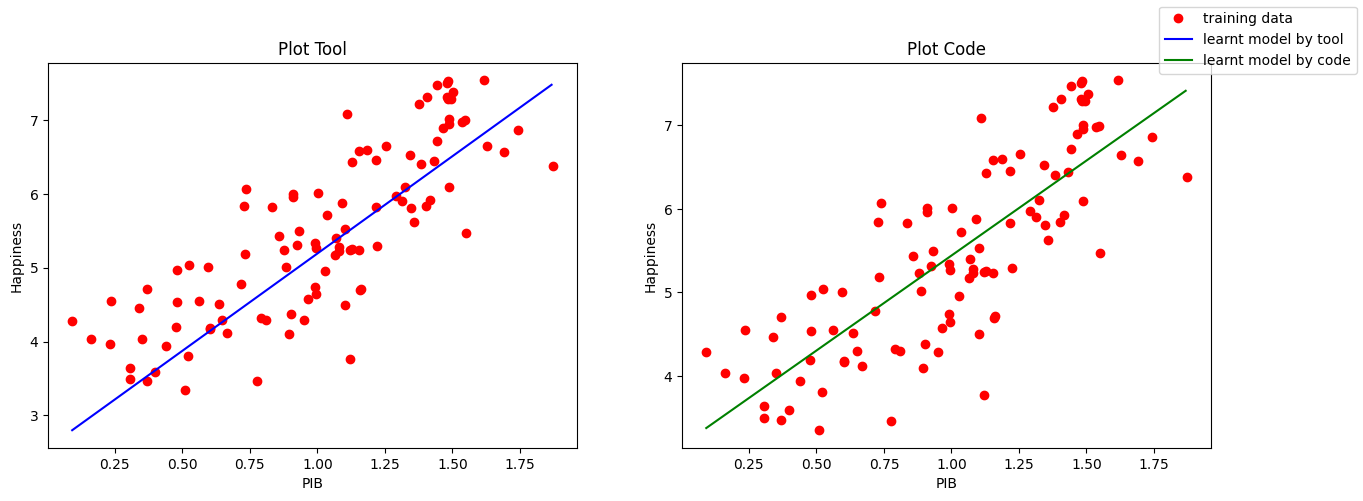

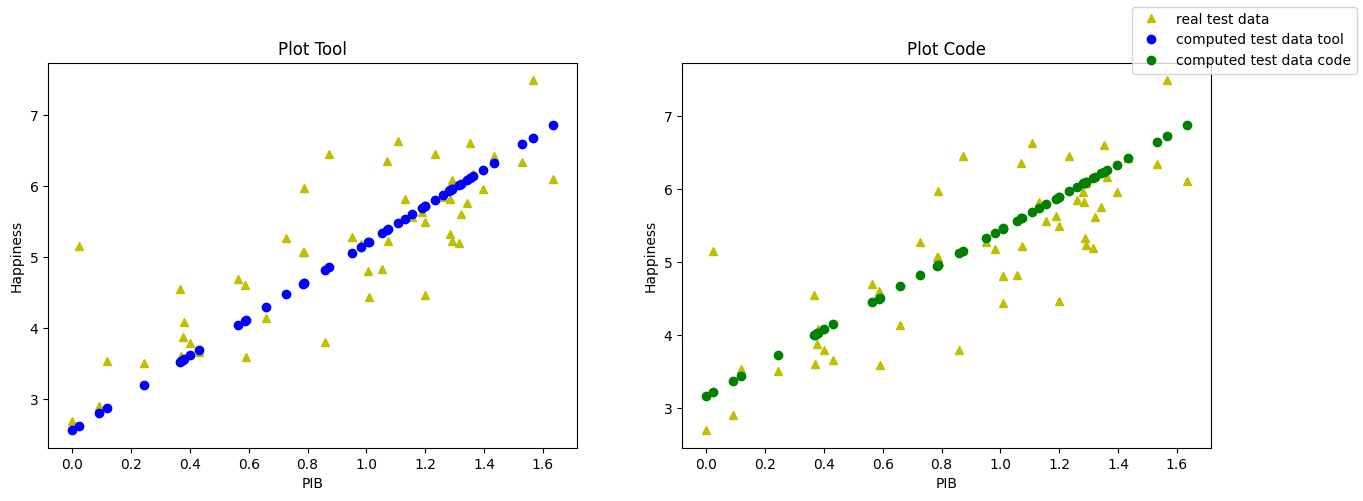

Erori outputs:
Eroare tool manuala : 0.48852052716765043
Eroare tool cu tool : 0.4241986474890991
Eroare code manuala : 0.48852052716765043
Eroare code cu tool : 0.42419864748909886
 < ------------- Iteration  3  -------------- >
the learnt model tool: f(x) =  2.6331929349313605  +  2.4283982642704784  * x
the learnt model code: f(x) =  3.3122460385721952  +  1.9685933637340756  * x


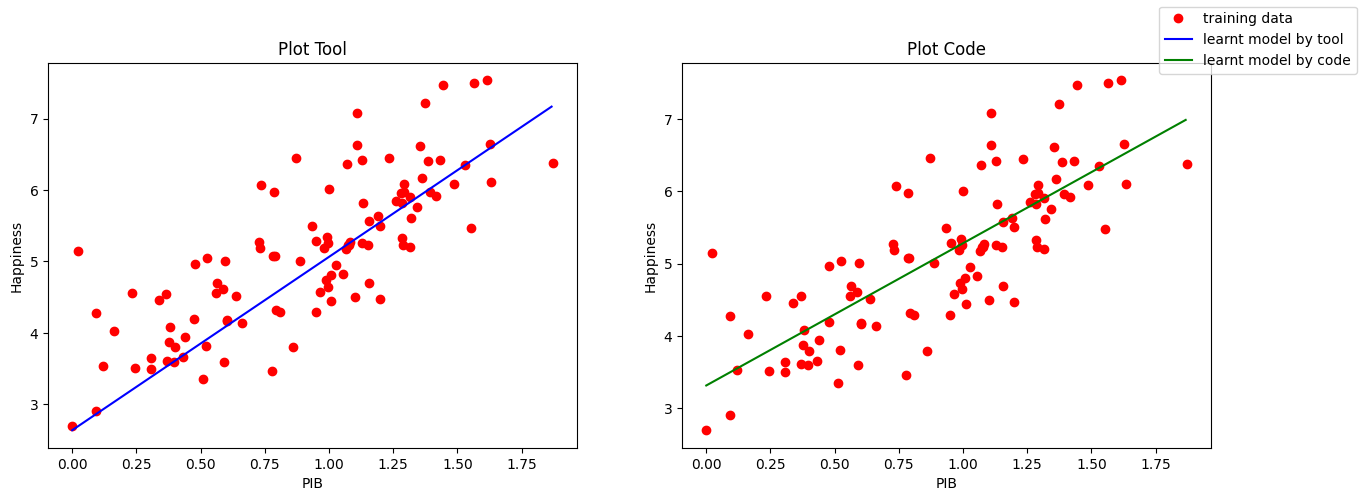

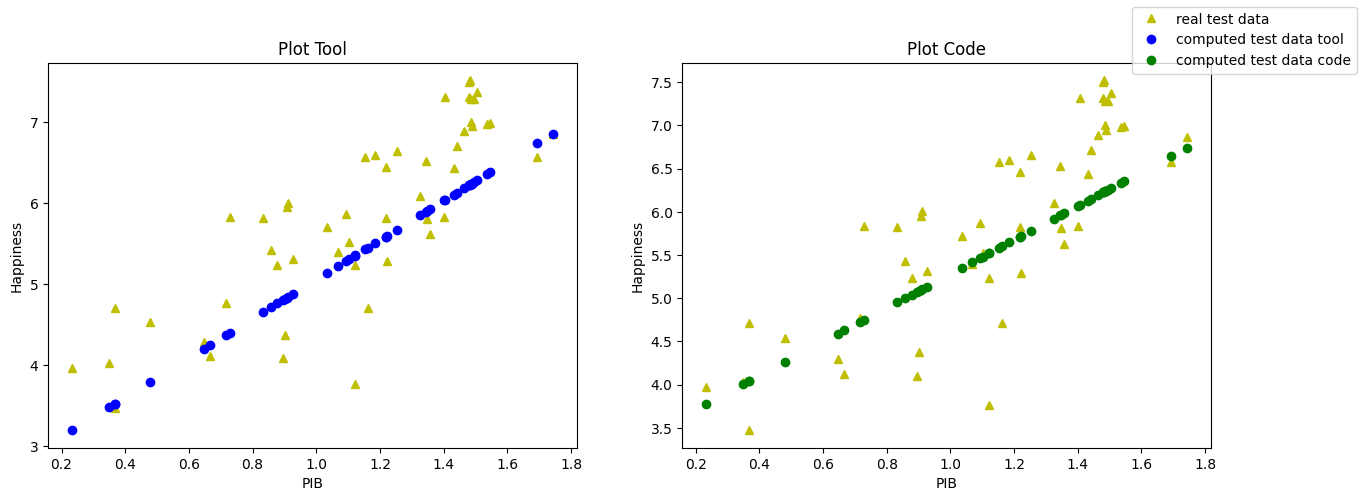

Erori outputs:
Eroare tool manuala : 0.6203545478882132
Eroare tool cu tool : 0.5272117292764954
Eroare code manuala : 0.620354547888213
Eroare code cu tool : 0.5272117292764953
 < ------------- Media Fields -------------- >
the learnt model tool: f(x) =  2.578125639616459  +  2.5700115457255994  * x
the learnt model tool: f(x) =  3.216828224292852  +  2.1713513797798267  * x


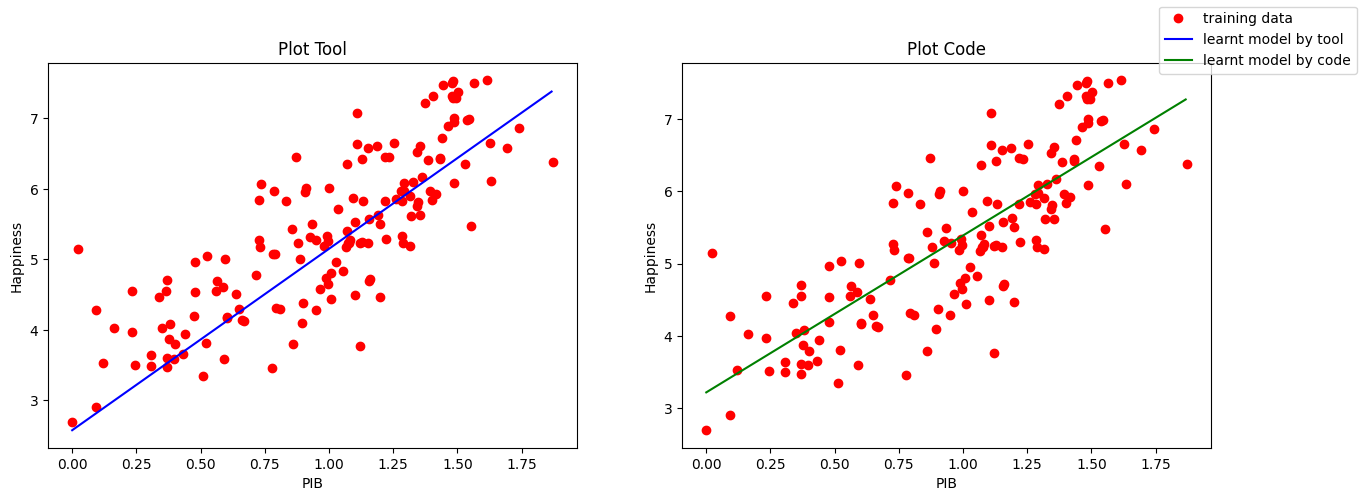

Erori outputs:
Eroare tool cu tool : 0.4321804987469523
Eroare code cu tool : 0.4321804987469521
======================================================= BATCH-URI =======================================================

 < ------------- Iteration  1  -------------- >
the learnt model tool: f(x) =  3.0844090638090385  +  2.3194475794330383  * x
the learnt model code: f(x) =  2.292452719738259  +  2.4528920531941503  * x


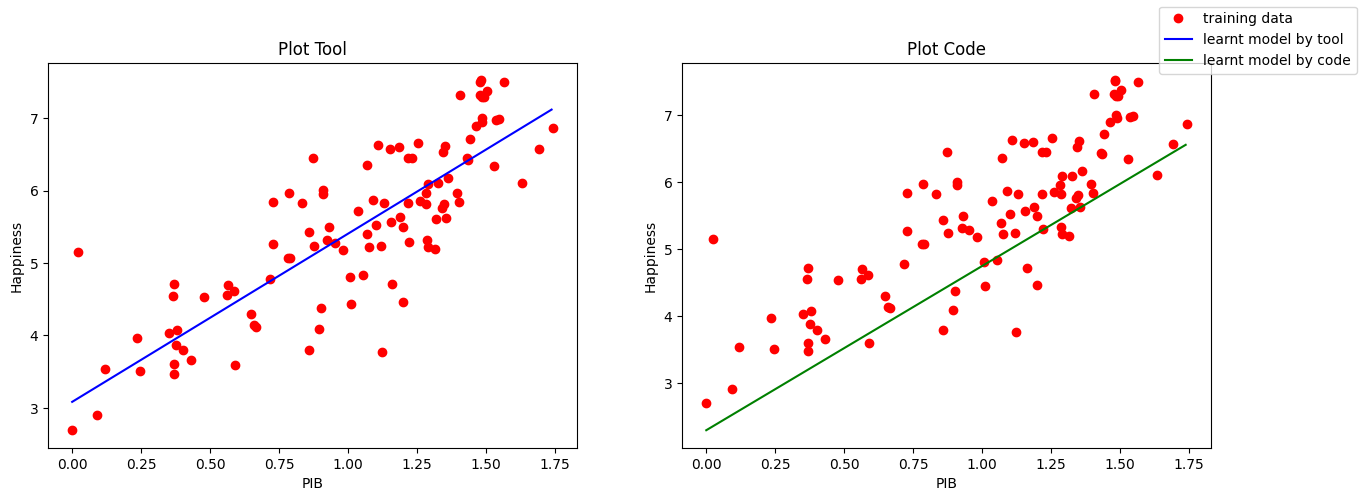

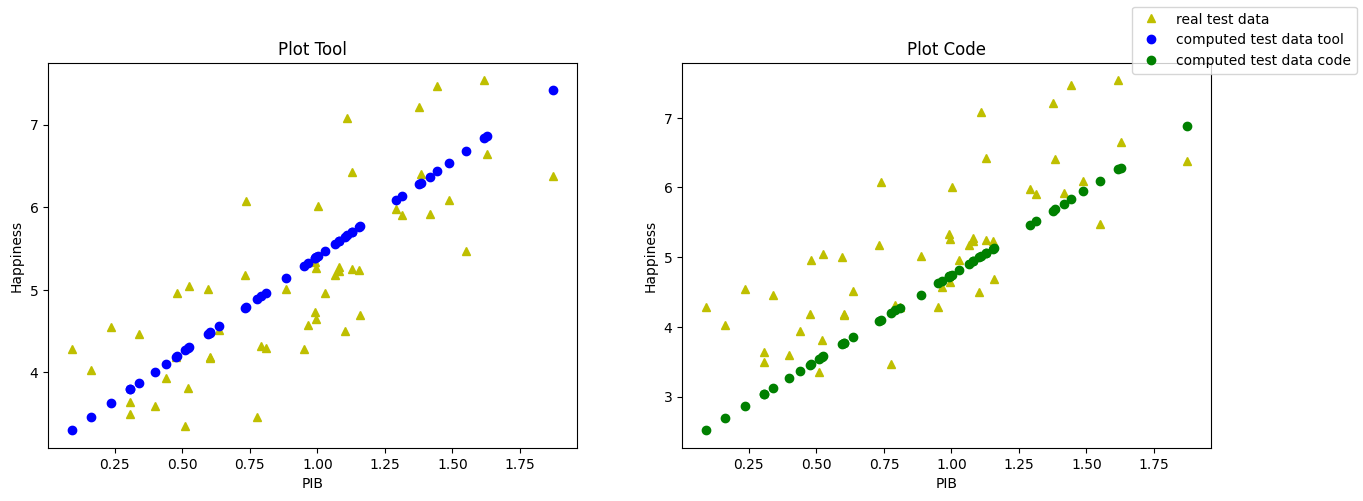

Erori outputs:
Eroare tool manuala : 0.4850859737705811
Eroare tool cu tool : 0.8133437160798609
Eroare code manuala : 0.485085973770581
Eroare code cu tool : 0.8133437160798612
 < ------------- Iteration  2  -------------- >
the learnt model tool: f(x) =  3.078826022219451  +  2.320556900290514  * x
the learnt model code: f(x) =  2.2976230182559956  +  2.4345216872932927  * x


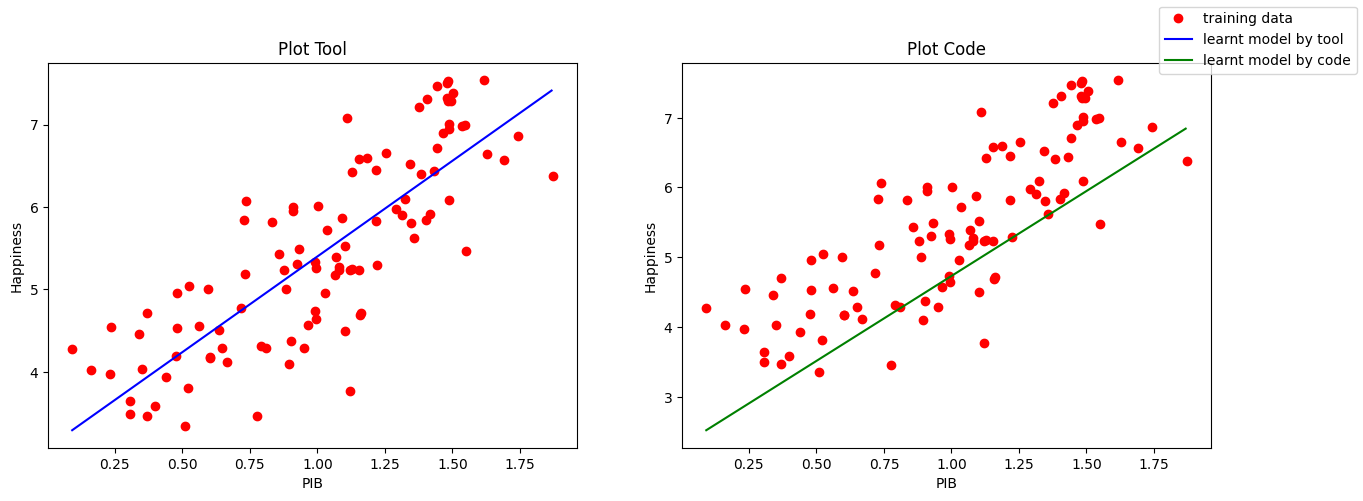

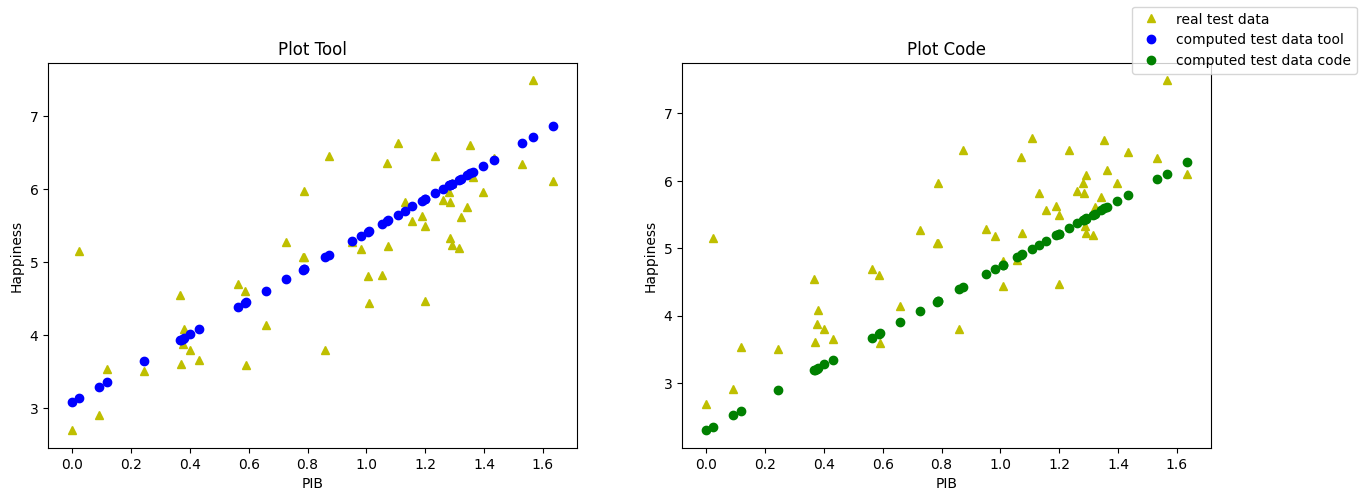

Erori outputs:
Eroare tool manuala : 0.4198686898183879
Eroare tool cu tool : 0.7680811627368129
Eroare code manuala : 0.419868689818388
Eroare code cu tool : 0.7680811627368129
 < ------------- Iteration  3  -------------- >
the learnt model tool: f(x) =  3.227845494663475  +  2.023218555237982  * x
the learnt model code: f(x) =  2.3027775556960592  +  2.200126230775458  * x


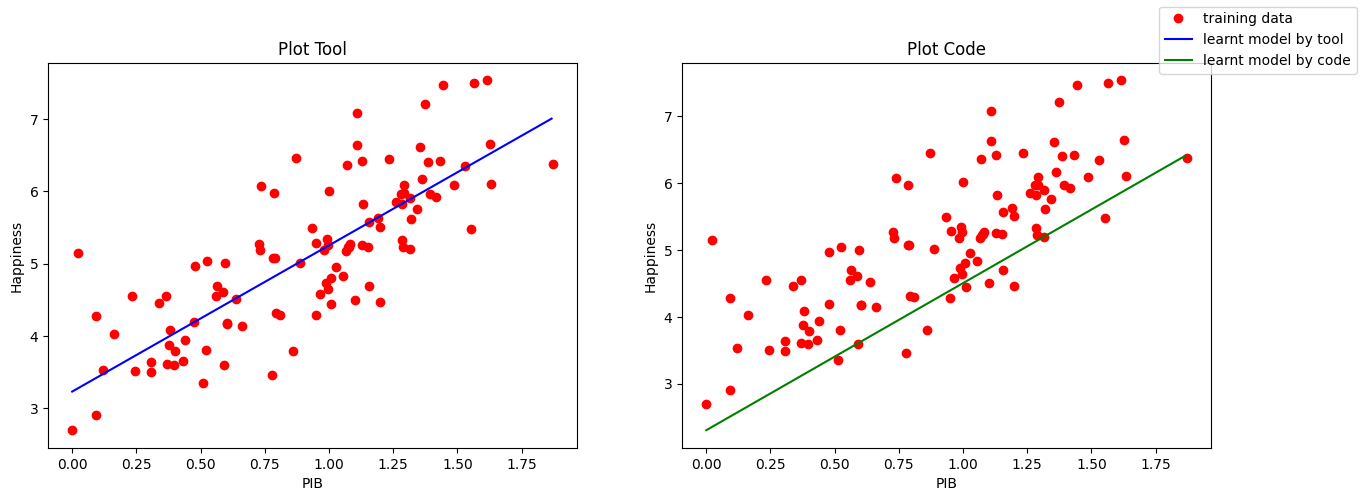

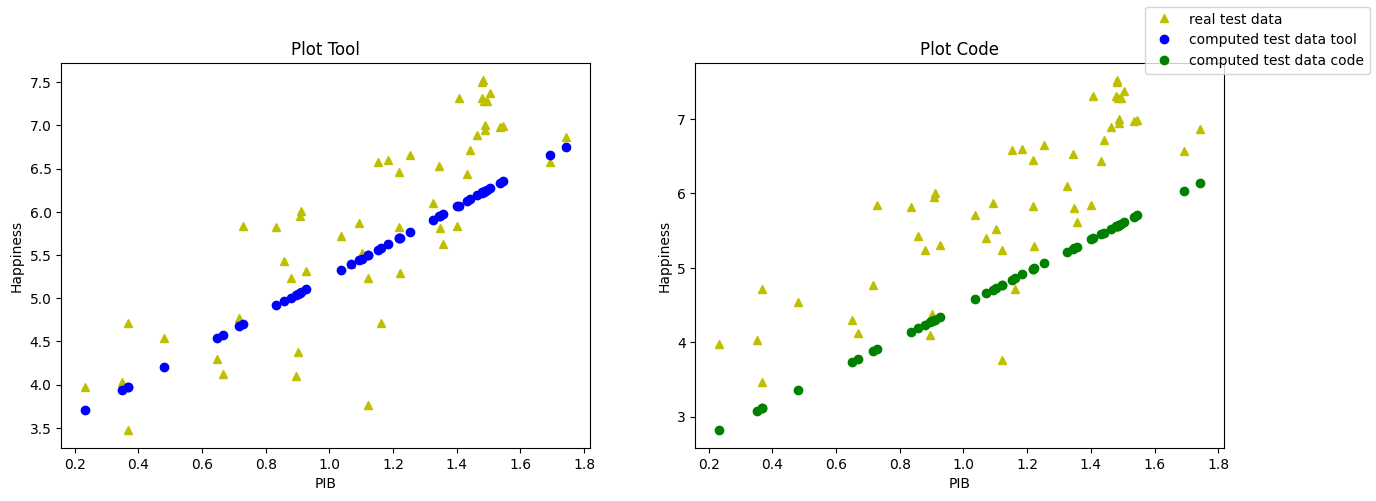

Erori outputs:
Eroare tool manuala : 0.5350954503645327
Eroare tool cu tool : 1.5398892325623381
Eroare code manuala : 0.5350954503645327
Eroare code cu tool : 1.5398892325623381
 < ------------- Media Fields -------------- >
the learnt model tool: f(x) =  3.130360193563988  +  2.221074344987178  * x
the learnt model tool: f(x) =  2.2976177645634377  +  2.3625133237543  * x


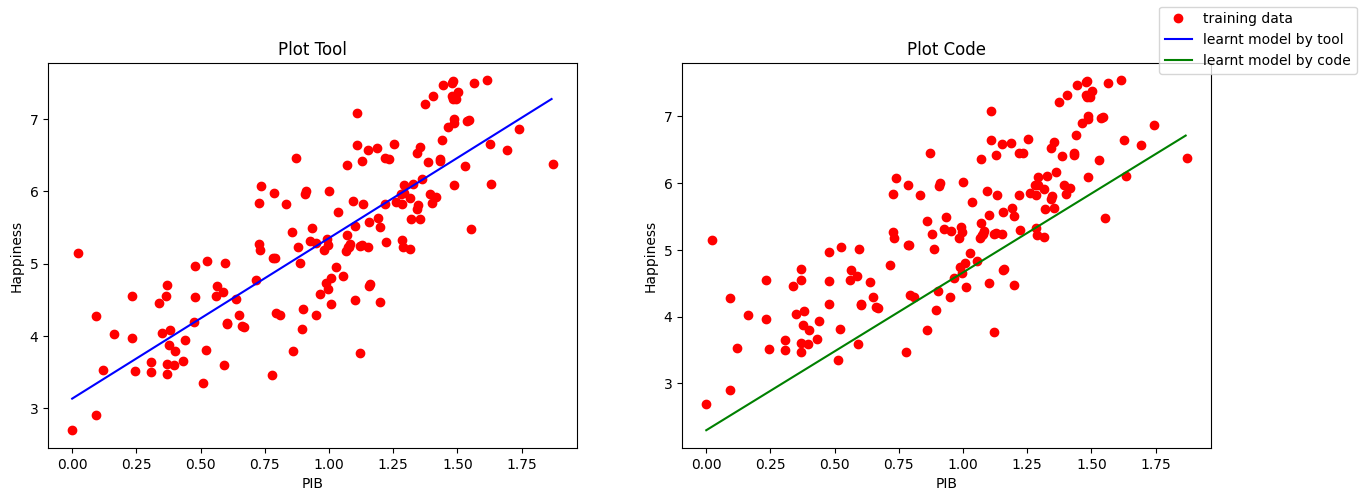

Erori outputs:
Eroare tool cu tool : 0.9706330424200575
Eroare code cu tool : 0.9706330424200575


In [42]:
# Citim datele
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'dataLab6','2017.csv' )

inputs,outputs = ReadSingleInputCSV(filePath,'Economy..GDP.per.Capita.','Happiness.Score')
inputs = [float(el) for el in inputs]
outputs = [float(el) for el in outputs]

#histograma
dp.plotDataHistogram(inputs,'PIB')
dp.plotDataHistogram(outputs,'Happiness')

#plot data liniar
dp.PlotLiniarData(inputs,outputs,'PIB','Happiness')

#k sets
QuatroTV = kFodsCrossTrainData([[x] for x in inputs],outputs,3,seed=54)

#perechile de parametri
wList = []

print("======================================================= STOCASTIC =======================================================" )
print()
i = 1;
for TI,TO,VI,VO in QuatroTV:
    print (" < ------------- Iteration ",i," -------------- >")
    i += 1
    wList.append(SolveForSetStocastic(TI,TO,VI,VO))
    
print (" < ------------- Media Fields -------------- >")
#tool
tw0 = np.mean([w[0] for w in wList])
tw1 = np.mean([w[1] for w in wList])
print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x')
#code
cw0 = np.mean([w[2] for w in wList])
cw1 = np.mean([w[3] for w in wList])
print('the learnt model tool: f(x) = ', cw0, ' + ', cw1, ' * x')

#Plot pentru Learning data din tool si code si compararea lor
dp.Compare_LiniarData(inputs,outputs,tw0,tw1,cw0,cw1,'PIB','Happiness')

#Computed pentru codul propiru
cc = myRegressor.predict([[x] for x in inputs],[cw1,cw0])

#Erori
print("Erori outputs:")
print(f"Eroare tool cu tool : {err.ManualError(cc, outputs)}")
print(f"Eroare code cu tool : {err.ToolError(cc, outputs)}")

print("======================================================= BATCH-URI =======================================================")
print()
wList = []

i = 1;
for TI,TO,VI,VO in QuatroTV:
    print (" < ------------- Iteration ",i," -------------- >")
    i += 1
    wList.append(SolveForSetBatches(TI,TO,VI,VO))

print (" < ------------- Media Fields -------------- >")
#tool
tw0 = np.mean([w[0] for w in wList])
tw1 = np.mean([w[1] for w in wList])
print('the learnt model tool: f(x) = ', tw0, ' + ', tw1, ' * x')
#code
cw0 = np.mean([w[2] for w in wList])
cw1 = np.mean([w[3] for w in wList])
print('the learnt model tool: f(x) = ', cw0, ' + ', cw1, ' * x')

#Plot pentru Learning data din tool si code si compararea lor
dp.Compare_LiniarData(inputs,outputs,tw0,tw1,cw0,cw1,'PIB','Happiness')

#Computed pentru codul propiru
cc = myRegressor.predict([[x] for x in inputs],[cw1,cw0])

#Erori outputs
print("Erori outputs:")
print(f"Eroare tool cu tool : {err.ManualError(cc, outputs)}")
print(f"Eroare code cu tool : {err.ToolError(cc, outputs)}")
    

## - investigarea diferitelor funcții de loss

### Cea folosita dealungul programului este MSE , dar voi mai oferi inca 2 functii de loss : 

#### - BCE : Binary Cross Entropy
Binary Cross-Entropy (sau log loss) este o funcție de pierdere folosită când ai o problemă de clasificare binară
     – adică două clase posibile (de ex. "spam" sau "nu spam", "pisică" sau "nu pisică").
Pentru un set de \( n \) exemple:

$$
{BCE} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right]
$$
unde:
- $ y_i \in \{0, 1\} $: etichetele reale
- $ \hat{y}_i \in (0, 1) $: predicțiile modelului (probabilități) 

In [ ]:
er = err.BCE(BCE_realData, BCE_computedData)

print(f'Binary Cross Entropy: {er} %')

### CSE : Categorial Cross Entropy
Este o funcție de pierdere (loss function) folosită când ai de clasificat exemple în mai multe clase (multi-class classification).
Scopul ei este să măsoare cât de "departe" este predicția modelului față de adevăr.
Cu cât modelul este mai precis, cu atât valoarea entropiei încrucișate este mai mică.

## Formula entropiei încrucișate categoriale

$$
L = - \sum_{i=1}^{C} y_i \cdot \log(p_i)
$$

unde:
- $ C $ = numărul de clase
- $ y_i $ = eticheta reală (1 dacă e clasa corectă, 0 altfel)
- $ p_i $ = probabilitatea prezisă pentru clasa $ i $

In [ ]:
prob = [procent_setosa,procent_versicolor,procent_virginica]

print(f'Categorical Cross Entropy: {err.CSE([1,0,0],prob)} %')

## - ce se întîmplă în cazul clasificarii binare daca se modifică pragul de decizie din 0.5 în alte valori. Cum se poate aprecia calitatea clasificatorului pentru diferite valori ale pragului?

Atunci cand pragul de decizie se schimba clasificator-ul va avea un comportament diferit in functie de contextul acestuia
Atunci cand :
- este mai mic de 0.5 , este mai sensitiv , creste sansele de True Pozitiv dar si Fals pozitiv, va creste precizia va fi mai mica , dar recall-ul mai mare astfel , deoarce clasificatorul devine mai deschis la a pride toate valorile de adevar
- este mai mare de 0.5 , este mai specific , scad sansele de False Positive, dar cresc cele de False Negative. In acest caz, precizia va fi mai mare, dar recall-ul va scadea, deoarece clasificatorul devine mai strict cand vine vorba de o valoare de adevar